In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
import statsmodels.stats

In [3]:
monthly_data = pd.read_excel("dane.xlsx", sheet_name="miesięczne", parse_dates=["data"], index_col="data")
quarterly_data = pd.read_excel("dane.xlsx", sheet_name="kwartalne", parse_dates=["data"], index_col="data")
yearly_data = pd.read_excel("dane.xlsx", sheet_name="roczne", parse_dates=["data"], index_col="data")

            wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]
data                                                                               
1998-01-01                                        505032711.8                      
1999-01-01                                        360788067.1                      
2000-01-01                                        269565028.8                      
2001-01-01                                        136523655.7                      
2002-01-01                                        135057450.3                      
2003-01-01                                        274131011.7                      
2004-01-01                                        304633047.1                      
            wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]
data                                                                               
2005-01-01                                       2.828507e+08               

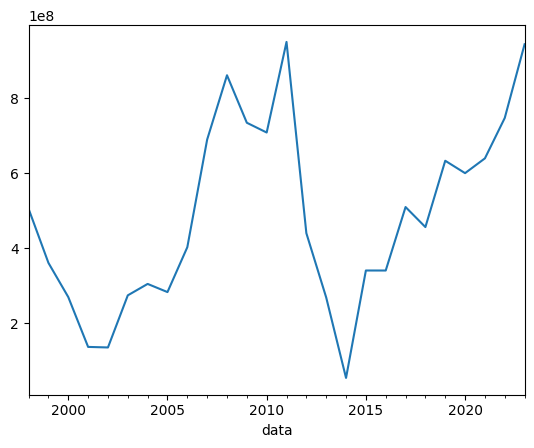

                                                       OLS Regression Results                                                      
Dep. Variable:     wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]   R-squared:                       0.297
Model:                                                                                 OLS   Adj. R-squared:                  0.156
Method:                                                                      Least Squares   F-statistic:                     2.111
Date:                                                                     Wed, 25 Mar 2026   Prob (F-statistic):              0.206
Time:                                                                             12:17:47   Log-Likelihood:                -138.87
No. Observations:                                                                        7   AIC:                             281.7
Df Residuals:                                                               

c:\Users\Parte\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
c:\Users\Parte\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [4]:
period1 = yearly_data[["wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]"]].loc[:"2004", :].dropna()
period2 = yearly_data[["wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]"]].loc["2005":, :].dropna()

print(period1)
print(period2)

yearly_data["wydatki inwestycyjne na infrastrukturę kolejową w cenach stałych [euro]"].dropna().plot()
plt.show()

trend1 = pd.DataFrame(range(1, len(period1) + 1), index=period1.index, columns=["t"])
trend2 = pd.DataFrame(range(len(period1) + 1, len(period1) + 20), index=period2.index, columns=["t"])

trend1 = sm.add_constant(trend1)
trend2 = sm.add_constant(trend2)

OLSmodel1 = sm.OLS(period1, trend1)
OLSmodel2 = sm.OLS(period2, trend2)

OLSresults1 = OLSmodel1.fit()
OLSresults2 = OLSmodel2.fit()

print(OLSresults1.summary())
print(OLSresults2.summary())